# Classifier Test-Set Metrics — Accuracy, ROC-AUC, PR-AUC

Loads the two trained classifiers and evaluates them on the held-out test set.

| Model | Checkpoint |
|---|---|
| SimpleCNN + geometric augmentation | `models/augmented_cnn_20260615-001836.pt` |
| SimpleCNN + CycleGAN synthetic augmentation | `models/cyclegan_augmented_cnn_20260615-232507.pt` |

**Threshold selection:** Youden's J on the validation set (`argmax TPR − FPR`).

**Metrics reported:**
- Accuracy (at Youden threshold)
- ROC-AUC
- PR-AUC (`average_precision_score`)
- Confusion matrix

## 1. Setup

In [1]:
import sys
from pathlib import Path

project_root = Path("../").resolve()
sys.path.insert(0, str(project_root / "utils"))
sys.path.insert(0, str(project_root / "models"))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    average_precision_score, precision_recall_curve,
    confusion_matrix,
)

from classifier import SimpleCNN
from device import DEVICE
from train_models import run_epoch

DATA_CACHE_DIR = project_root / "data" / "processed"
MODELS_DIR     = project_root / "models"
RESULTS_DIR    = project_root / "results"

print(f"Device: {DEVICE}")
print(f"Project root: {project_root}")

Device: cuda
Project root: C:\Users\User\Documents\0Unicamp\IA376N\Projeto\dgm-2026.1\projects\ecgpcx-ray


## 2. Load Datasets

In [2]:
val_dataset  = torch.load(DATA_CACHE_DIR / "val_dataset.pt",  weights_only=False)
test_dataset = torch.load(DATA_CACHE_DIR / "test_dataset.pt", weights_only=False)

BATCH_SIZE = 64
val_loader  = DataLoader(val_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

test_labels = test_dataset.labels[:, 1].numpy()
n_pos = int(test_labels.sum())
n_neg = len(test_labels) - n_pos

print(f"Val  samples : {len(val_dataset)}")
print(f"Test samples : {len(test_dataset)}  (healthy: {n_neg}, pneumonia: {n_pos}, {n_pos/len(test_labels)*100:.2f}% positive)")

Val  samples : 8993
Test samples : 9021  (healthy: 8978, pneumonia: 43, 0.48% positive)


## 3. Helper Functions

In [3]:
def get_predictions(loader, model, device):
    """Run inference and return (y_true, logits) as numpy arrays."""
    criterion = nn.BCEWithLogitsLoss()
    _, y_true, logits = run_epoch(loader, model.to(device), criterion, device=device)
    return np.array(y_true), np.array(logits)


def youden_threshold(y_val, logits_val):
    """Select decision threshold by maximising TPR - FPR on the validation set."""
    fpr, tpr, thresholds = roc_curve(y_val, logits_val)
    idx = np.argmax(tpr - fpr)
    return float(thresholds[idx])


def f1_threshold(y_val, logits_val):
    """Select decision threshold by maximising F1 on the validation set.

    precision_recall_curve accepts raw logits — thresholds are returned in the
    same space (logits), consistent with compute_metrics.
    """
    prec, rec, thresholds = precision_recall_curve(y_val, logits_val)
    # last point is (prec=1, rec=0) with no associated threshold → drop it
    f1 = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    idx = np.argmax(f1)
    return float(thresholds[idx]), float(f1[idx])


def compute_metrics(y_true, logits, threshold):
    """Return dict of Accuracy, ROC-AUC, PR-AUC and confusion matrix."""
    probs = torch.sigmoid(torch.tensor(logits)).numpy()
    preds = (logits >= threshold).astype(int)

    acc     = float((preds == y_true).mean())
    roc_auc = float(roc_auc_score(y_true, logits))
    pr_auc  = float(average_precision_score(y_true, probs))
    cm      = confusion_matrix(y_true, preds)

    return {
        "accuracy": acc,
        "roc_auc":  roc_auc,
        "pr_auc":   pr_auc,
        "threshold": threshold,
        "confusion_matrix": cm,
        "y_true":  y_true,
        "logits":  logits,
        "probs":   probs,
    }

## 4. Model Definitions

In [4]:
MODELS = [
    {
        "label":      "SimpleCNN + Geometric Aug",
        "checkpoint": MODELS_DIR / "augmented_cnn_20260615-001836.pt",
        "dropout":    0.3,
    },
    {
        "label":      "SimpleCNN + CycleGAN Aug",
        "checkpoint": MODELS_DIR / "cyclegan_augmented_cnn_20260615-232507.pt",
        "dropout":    0.3,
    },
]

## 5. Evaluate Both Models

In [5]:
results = []

for cfg in MODELS:
    print(f"\n{'='*60}")
    print(f"Model: {cfg['label']}")
    print(f"Checkpoint: {cfg['checkpoint'].name}")
    print('='*60)

    model = SimpleCNN(dropout_rate=cfg["dropout"])
    state = torch.load(cfg["checkpoint"], map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()

    # Validation inference → threshold
    y_val, logits_val = get_predictions(val_loader, model, DEVICE)
    threshold = youden_threshold(y_val, logits_val)
    print(f"Youden threshold (val): {threshold:.6f}")

    # Test inference → metrics
    y_test, logits_test = get_predictions(test_loader, model, DEVICE)
    m = compute_metrics(y_test, logits_test, threshold)
    m["label"] = cfg["label"]
    results.append(m)

    cm = m["confusion_matrix"]
    tn, fp, fn, tp = cm.ravel()
    print(f"Accuracy : {m['accuracy']:.4f}")
    print(f"ROC-AUC  : {m['roc_auc']:.4f}")
    print(f"PR-AUC   : {m['pr_auc']:.4f}")
    print(f"Confusion matrix:")
    print(f"  TN={tn}  FP={fp}")
    print(f"  FN={fn}  TP={tp}")


Model: SimpleCNN + Geometric Aug
Checkpoint: augmented_cnn_20260615-001836.pt
Youden threshold (val): 0.099641
Accuracy : 0.4255
ROC-AUC  : 0.5790
PR-AUC   : 0.0098
Confusion matrix:
  TN=3808  FP=5170
  FN=13  TP=30

Model: SimpleCNN + CycleGAN Aug
Checkpoint: cyclegan_augmented_cnn_20260615-232507.pt
Youden threshold (val): 0.008211
Accuracy : 0.5047
ROC-AUC  : 0.6257
PR-AUC   : 0.0117
Confusion matrix:
  TN=4523  FP=4455
  FN=13  TP=30


## 6. Comparison Table

In [6]:
rows = []
for m in results:
    cm = m["confusion_matrix"]
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rows.append({
        "Model":     m["label"],
        "Threshold": f"{m['threshold']:.4f}",
        "Accuracy":  f"{m['accuracy']:.4f}",
        "ROC-AUC":   f"{m['roc_auc']:.4f}",
        "PR-AUC":    f"{m['pr_auc']:.4f}",
        "Recall":    f"{recall:.4f}",
        "Precision": f"{precision:.4f}",
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    })

df = pd.DataFrame(rows).set_index("Model")
df

,Threshold,Accuracy,ROC-AUC,PR-AUC,Recall,Precision,TP,FP,TN,FN
Model,,,,,,,,,,
SimpleCNN + Geometric Aug,0.0996,0.4255,0.5790,0.0098,0.6977,0.0058,30,5170,3808,13
SimpleCNN + CycleGAN Aug,0.0082,0.5047,0.6257,0.0117,0.6977,0.0067,30,4455,4523,13


## 7. ROC and PR Curves

Saved: C:\Users\User\Documents\0Unicamp\IA376N\Projeto\dgm-2026.1\projects\ecgpcx-ray\results\classifier_comparison_curves.png


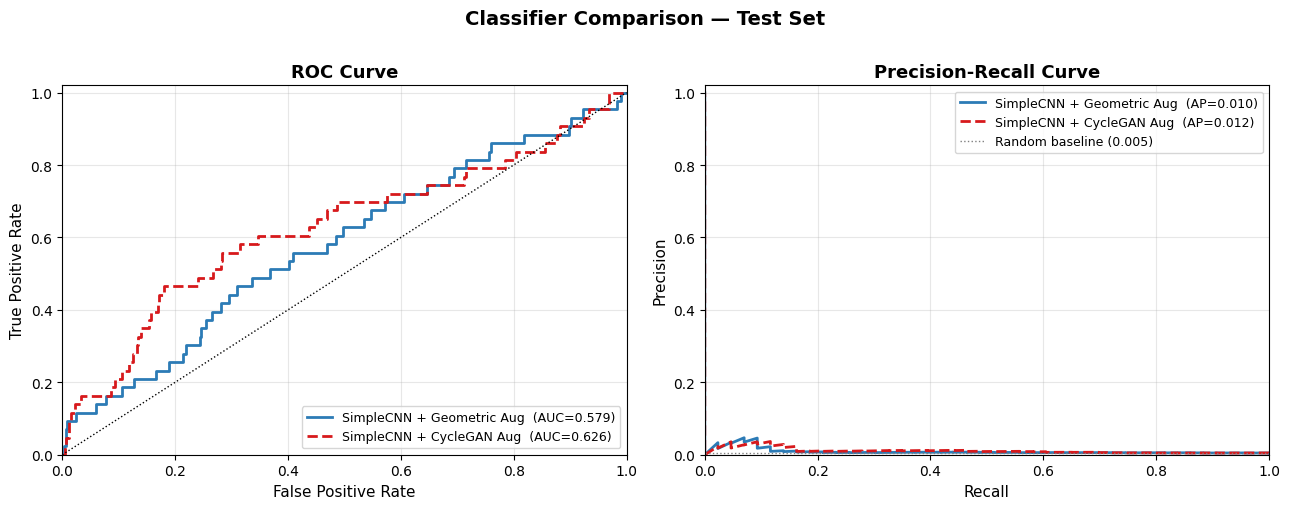

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#2c7bb6", "#d7191c"]
linestyles = ["-", "--"]

# --- ROC curves ---
ax = axes[0]
for m, color, ls in zip(results, colors, linestyles):
    fpr, tpr, _ = roc_curve(m["y_true"], m["logits"])
    ax.plot(fpr, tpr, color=color, ls=ls, lw=2,
            label=f"{m['label']}  (AUC={m['roc_auc']:.3f})")
ax.plot([0, 1], [0, 1], "k:", lw=1)
ax.set_xlabel("False Positive Rate", fontsize=11)
ax.set_ylabel("True Positive Rate", fontsize=11)
ax.set_title("ROC Curve", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)

# --- PR curves ---
ax = axes[1]
baseline = results[0]["y_true"].mean()
for m, color, ls in zip(results, colors, linestyles):
    prec, rec, _ = precision_recall_curve(m["y_true"], m["probs"])
    ax.plot(rec, prec, color=color, ls=ls, lw=2,
            label=f"{m['label']}  (AP={m['pr_auc']:.3f})")
ax.axhline(baseline, color="gray", ls=":", lw=1, label=f"Random baseline ({baseline:.3f})")
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Precision-Recall Curve", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.3)

fig.suptitle("Classifier Comparison — Test Set", fontsize=14, fontweight="bold", y=1.01)
fig.tight_layout()

out_path = RESULTS_DIR / "classifier_comparison_curves.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved: {out_path}")
plt.show()

## 8. Save Results to CSV

In [8]:
out_csv = RESULTS_DIR / "classifier_test_metrics.csv"
df.to_csv(out_csv)
print(f"Saved: {out_csv}")
df

Saved: C:\Users\User\Documents\0Unicamp\IA376N\Projeto\dgm-2026.1\projects\ecgpcx-ray\results\classifier_test_metrics.csv


,Threshold,Accuracy,ROC-AUC,PR-AUC,Recall,Precision,TP,FP,TN,FN
Model,,,,,,,,,,
SimpleCNN + Geometric Aug,0.0996,0.4255,0.5790,0.0098,0.6977,0.0058,30,5170,3808,13
SimpleCNN + CycleGAN Aug,0.0082,0.5047,0.6257,0.0117,0.6977,0.0067,30,4455,4523,13


## 9. Evaluate with F1-Optimal Threshold

Re-uses the logits already computed in section 5 — no second forward pass on the test set needed.  
The threshold is selected on the **validation set** by maximising F1 (`2·P·R / (P+R)`).

In [9]:
results_f1 = []

for cfg, r in zip(MODELS, results):
    print(f"\n{'='*60}")
    print(f"Model: {cfg['label']}")
    print('='*60)

    model = SimpleCNN(dropout_rate=cfg["dropout"])
    state = torch.load(cfg["checkpoint"], map_location=DEVICE)
    model.load_state_dict(state)
    model.eval()

    # Validation inference → F1-optimal threshold
    y_val, logits_val = get_predictions(val_loader, model, DEVICE)
    thr, best_f1_val = f1_threshold(y_val, logits_val)
    print(f"F1-optimal threshold (val): {thr:.6f}  (val F1={best_f1_val:.4f})")

    # Evaluate on test set using logits already stored in results
    m = compute_metrics(r["y_true"], r["logits"], thr)
    m["label"] = cfg["label"]
    results_f1.append(m)

    cm = m["confusion_matrix"]
    tn, fp, fn, tp = cm.ravel()
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1_test   = 2 * precision * recall / (precision + recall + 1e-8)
    print(f"Accuracy  : {m['accuracy']:.4f}")
    print(f"ROC-AUC   : {m['roc_auc']:.4f}")
    print(f"PR-AUC    : {m['pr_auc']:.4f}")
    print(f"F1 (test) : {f1_test:.4f}  (Recall={recall:.4f}, Precision={precision:.4f})")
    print(f"Confusion matrix:")
    print(f"  TN={tn}  FP={fp}")
    print(f"  FN={fn}  TP={tp}")


Model: SimpleCNN + Geometric Aug
F1-optimal threshold (val): 0.297784  (val F1=0.0256)
Accuracy  : 0.9559
ROC-AUC   : 0.5790
PR-AUC    : 0.0098
F1 (test) : 0.0245  (Recall=0.1163, Precision=0.0137)
Confusion matrix:
  TN=8618  FP=360
  FN=38  TP=5

Model: SimpleCNN + CycleGAN Aug
F1-optimal threshold (val): 0.017617  (val F1=0.0234)
Accuracy  : 0.8472
ROC-AUC   : 0.6257
PR-AUC    : 0.0117
F1 (test) : 0.0213  (Recall=0.3488, Precision=0.0110)
Confusion matrix:
  TN=7628  FP=1350
  FN=28  TP=15


In [10]:
# Side-by-side comparison: Youden vs F1 threshold
def summary_row(m, strategy):
    cm = m["confusion_matrix"]
    tn, fp, fn, tp = cm.ravel()
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec + 1e-8)
    return {
        "Model":     m["label"],
        "Strategy":  strategy,
        "Threshold": f"{m['threshold']:.4f}",
        "Accuracy":  f"{m['accuracy']:.4f}",
        "Recall":    f"{rec:.4f}",
        "Precision": f"{prec:.4f}",
        "F1":        f"{f1:.4f}",
        "ROC-AUC":   f"{m['roc_auc']:.4f}",
        "PR-AUC":    f"{m['pr_auc']:.4f}",
        "TP": tp, "FP": fp, "TN": tn, "FN": fn,
    }

comp_rows = (
    [summary_row(m, "Youden (TPR−FPR)") for m in results] +
    [summary_row(m, "Max-F1")           for m in results_f1]
)
df_comp = pd.DataFrame(comp_rows).set_index(["Model", "Strategy"])
df_comp

,,Threshold,Accuracy,Recall,Precision,F1,ROC-AUC,PR-AUC,TP,FP,TN,FN
Model,Strategy,,,,,,,,,,,
SimpleCNN + Geometric Aug,Youden (TPR−FPR),0.0996,0.4255,0.6977,0.0058,0.0114,0.5790,0.0098,30,5170,3808,13
SimpleCNN + CycleGAN Aug,Youden (TPR−FPR),0.0082,0.5047,0.6977,0.0067,0.0133,0.6257,0.0117,30,4455,4523,13
SimpleCNN + Geometric Aug,Max-F1,0.2978,0.9559,0.1163,0.0137,0.0245,0.5790,0.0098,5,360,8618,38
SimpleCNN + CycleGAN Aug,Max-F1,0.0176,0.8472,0.3488,0.0110,0.0213,0.6257,0.0117,15,1350,7628,28
